# Actividad 2




Esta actividad consiste en la realización de la actividad evaluable número 2 asociada al bloque 2 de la asignatura. En ella, se deben construir diferentes versiones de redes neuronales con 3 y 4 capas ocultas, y además, probar con diferentes valores del hiperparámetro de aprendizaje (`learning_rate`) y comparar los resultados obtenidos.

Para llevar a cabo la actividad, he dividido el enunciado en cuatro diferentes experimentos, siendo:

- **Experimento 1:**  Entrenar una red neuronal con **3 capas ocultas** utilizando el factor de aprendizaje (`learning_rate`) de **3e-1** que utiliza el ejercicio 10 citado por el enunciado. Probar con al menos **dos configuraciones distintas de número de neuronas** en las capas ocultas y comparar los resultados.  

- **Experimento 2:**  Entrenar una red neuronal con **4 capas ocultas** utilizando el mismo `learning_rate` de **3e-1**. Probar también con al menos **dos configuraciones diferentes de número de neuronas** en las capas ocultas y comparar los resultados.  

- **Experimento 3:** Seleccionar la mejor red del Experimento 1 (red de 3 capas ocultas) y ajustar el `learning_rate` a otros valores distintos del original (**3e-1**) para evaluar su impacto en el rendimiento.  

- **Experimento 4:** Seleccionar la mejor red del Experimento 2 (red de 4 capas ocultas) y cambiar su `learning_rate` para probar cómo afecta al rendimiento, en comparación con los resultados originales obtenidos con `learning_rate=3e-1`.  


## Configuración de los Requisitos

Este proyecto requiere:
- Python 3.7 o superior
- Scikit-Learn ≥ 1.0.1
- TensorFlow ≥ 2.8

In [1]:
import sys
from packaging import version
import sklearn
import tensorflow as tf
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

assert sys.version_info >= (3, 7)
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")
assert version.parse(tf.__version__) >= version.parse("2.8.0")

Vamos a definir los tamaños de fuente por defecto para que las figuras queden más bonitas:

In [2]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

## Cargar el dataset

En esta sección cargaremos el dataset necesario para la Actividad 2.

In [3]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

El conjunto de entrenamiento MNIST contiene 60.000 imágenes en escala de grises, cada una de 28x28 píxeles:

In [4]:
X_train_full.shape

(60000, 28, 28)

La intensidad de cada píxel también se representa como un byte (de 0 a 255):

In [5]:
X_train_full.dtype

dtype('uint8')

Vamos a dividir el conjunto de entrenamiento completo en un conjunto de validación y un conjunto de entrenamiento (más pequeño).

También reducimos las intensidades de los píxeles al rango 0-1 y las convertimos en flotantes, dividiéndolas por 255:

In [6]:
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.

Vamos a graficar una imagen utilizando la función `imshow()` de Matplotlib, con un mapa de colores `'binary'`:

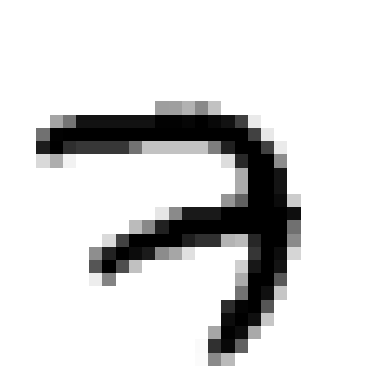

In [7]:
plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

Las etiquetas son los IDs de las clases (representados como uint8), que van del 0 al 9. De manera conveniente, los IDs de las clases corresponden a los dígitos representados en las imágenes, por lo que no necesitamos un array de `class_names`:

In [8]:
y_train

array([7, 3, 4, ..., 5, 6, 8], dtype=uint8)

El conjunto de validación contiene 5.000 imágenes y el conjunto de prueba, 10.000:

In [9]:
X_valid.shape

(5000, 28, 28)

In [10]:
X_test.shape

(10000, 28, 28)

Veamos una muestra de las imágenes del conjunto de datos:

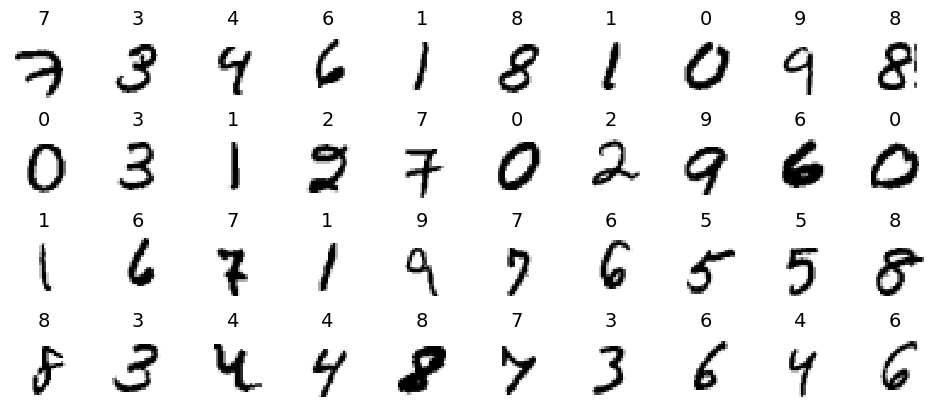

In [11]:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(y_train[index])
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

## Experimento 1: Red con 3 capas ocultas y learning_rate=3e-1

El objetivo de este experimento es entrenar una red neuronal con **3 capas ocultas** utilizando el factor de aprendizaje (`learning_rate`) de **3e-1**. Hay que probar con al menos **dos configuraciones distintas de número de neuronas** en las capas ocultas y comparar los resultados.  

### Bucle de experimentación con diferentes números de neuronas

Para implementar este experimento, he decidido crear un **bucle de exploración** para probar diferentes configuraciones de una red neuronal con 3 capas ocultas, ajustando el número de neuronas en cada capa en función de un rango predefinido (`neuron_range = [200, 300, 400]`). Con este enfoque he querido identificar la arquitectura más prometedora para una red de 3 capas ocultas con los datos dados.

Para limitar el número de experimentos, solo he considerado configuraciones donde el número de neuronas en las capas profundas sea igual o menor que la cantidad de neuronas en las capas superficiales. Para tomar esta decisión, he tenido en cuenta que habitualmente la extracción de características se realiza de manera jerárquica empezando en las capas más superficiales, y que por lo general, vamos reduciendo la dimensionalidad progresivamente según avanzamos en la red.

Para cada configuración:  
1. He **definido** el modelo con capas `Dense` usando `ReLU` como activación y una capa de salida `softmax` para clasificación.  
2. He **compilado** el modelo con `sparse_categorical_crossentropy` como función de pérdida y un optimizador SGD con `learning_rate=3e-1`.  
3. He implementado **callbacks**:
   - `EarlyStopping` para detener el entrenamiento si no hay mejora en la pérdida de validación durante 20 épocas.
   - `ModelCheckpoint` para guardar el mejor modelo de cada configuración.
   - `TensorBoard` para registrar métricas de entrenamiento.  
4. He **entrenado** el modelo durante un máximo de 100 épocas en los datos de entrenamiento, con validación en un conjunto aparte.  

Tras cada entrenamiento, he calculado las métricas de validación y he guardado los resultados junto con la configuración probada, para finalmente seleccionar la configuración que minimiza la pérdida de validación (`val_loss`) como la **mejor configuración**.  

In [12]:
# Limpiar cualquier sesión anterior de Keras y establecer semillas para reproducibilidad
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [13]:
# Rango de neuronas para explorar
neuron_range = [200, 300, 400]

# Inicializar una lista para guardar los resultados
results = []

# Establecer el índice de ejecución
run_index = 1

for n1 in neuron_range:  # Primer capa
    for n2 in neuron_range:  # Segunda capa
        for n3 in neuron_range:  # Tercera capa
            if n1 >= n2 >= n3:  # Solo probar si cada capa más superficial tiene un número de neuronas mayor o igual al de las capas más profundas 
                print(f"Probando configuración # {run_index}: {n1}-{n2}-{n3}")
                
                # Definir el modelo con la configuración actual
                model = tf.keras.Sequential([
                    tf.keras.layers.Flatten(input_shape=[28, 28]),
                    tf.keras.layers.Dense(n1, activation="relu"),
                    tf.keras.layers.Dense(n2, activation="relu"),
                    tf.keras.layers.Dense(n3, activation="relu"),
                    tf.keras.layers.Dense(10, activation="softmax")
                ])
                
                # Compilar el modelo
                model.compile(loss="sparse_categorical_crossentropy",
                              optimizer=tf.keras.optimizers.SGD(learning_rate=3e-1),
                              metrics=["accuracy"])
    
                # Definir el directorio de logs
                run_logdir = Path() / "mnist_logs/exp1" / "run_{:03d}".format(run_index)
    
                # Crear un callback de EarlyStopping que detendrá el entrenamiento si la pérdida no mejora durante 20 épocas
                early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20)
                
                # Crear un callback de ModelCheckpoint que guardará el modelo con la mejor puntuación de validación
                checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("model/exp1/mnist_model_{:03d}.keras".format(run_index), save_best_only=True)
                
                # Crear un callback de TensorBoard para registrar información de entrenamiento en un directorio de logs
                tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
                
                # Entrenar el modelo durante 100 épocas, utilizando todo lo anterior
                history = model.fit(X_train, y_train, epochs=100,
                                    validation_data=(X_valid, y_valid),
                                    callbacks=[checkpoint_cb, early_stopping_cb, tensorboard_cb],
                                    verbose=0)  # Silenciar salida

                # Obtener la mejor métrica de validación
                best_val_loss = min(history.history["val_loss"])
                best_val_loss_index = history.history["val_loss"].index(best_val_loss)
                best_val_accuracy = history.history["val_accuracy"][best_val_loss_index]
                accuracy = history.history["accuracy"][best_val_loss_index]
                loss = history.history["loss"][best_val_loss_index]
                
                # Guardar los resultados
                results.append((n1, n2, n3, best_val_accuracy, best_val_loss))
                print(f"Resultados para {n1}-{n2}-{n3}: accuracy={accuracy}, loss={loss}, val_accuracy={best_val_accuracy}, val_loss={best_val_loss}")
                
                run_index = run_index+1

# Encontrar la mejor configuración
best_config = min(results, key=lambda x: x[4])
print(f"Mejor configuración: {best_config}")

Probando configuración # 1: 200-200-200


C:\Users\maial\.conda\envs\unedenv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Resultados para 200-200-200: accuracy=0.9831636548042297, loss=0.052795179188251495, val_accuracy=0.9782000184059143, val_loss=0.07375628501176834
Probando configuración # 2: 300-200-200
Resultados para 300-200-200: accuracy=0.9955454468727112, loss=0.014762939885258675, val_accuracy=0.9819999933242798, val_loss=0.07671110332012177
Probando configuración # 3: 300-300-200
Resultados para 300-300-200: accuracy=0.9968000054359436, loss=0.01185400877147913, val_accuracy=0.98580002784729, val_loss=0.08015192300081253
Probando configuración # 4: 300-300-300
Resultados para 300-300-300: accuracy=0.9799818396568298, loss=0.06503876298666, val_accuracy=0.9779999852180481, val_loss=0.07595235854387283
Probando configuración # 5: 400-200-200
Resultados para 400-200-200: accuracy=0.9802727103233337, loss=0.06324338167905807, val_accuracy=0.9753999710083008, val_loss=0.0827290490269661
Probando configuración # 6: 400-300-200
Resultados para 400-300-200: accuracy=0.9807454347610474, loss=0.063465155

### Selección de dos modelos para comparar

He seleccionado las configuraciones 400-300-300 (modelo 7, el mejor elegido por el bucle) y 300-300-300 (modelo 4) para comparar. He querido comparar modelos que comparten una estructura similar para evaluar cómo afecta aumentar la complejidad del modelo añadiendo más neuronas en capas superficiales.

He aplicado el conjunto de datos de prueba a ambos modelos:

In [14]:
# Cargar el mejor modelo guardado durante el entrenamiento (el que obtuvo la mejor puntuación de validación)
model = tf.keras.models.load_model("./model/exp1/mnist_model_007.keras") # rollback al mejor modelo

# Evaluar el modelo cargado con los datos de prueba
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 658us/step - accuracy: 0.9769 - loss: 0.0836


[0.06916972994804382, 0.9800999760627747]

In [15]:
# Cargar otro para realizar la comparación
model = tf.keras.models.load_model("./model/exp1/mnist_model_004.keras")

# Evaluar el modelo cargado con los datos de prueba
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 641us/step - accuracy: 0.9709 - loss: 0.0978


[0.08051995933055878, 0.9760000109672546]

### Conclusiones Experimento 1 y Comparación de los dos modelos

**Conclusiones sobre el bucle de experimentación:**

El objetivo del bucle de experimentación ha sido explorar diferentes configuraciones de una red neuronal con 3 capas ocultas, probando combinaciones de 200, 300 y 400 neuronas en cada capa, asegurándote de que el número de neuronas disminuye o se mantiene constante hacia las capas profundas. Estos han sido las conclusiones más destacables de este experimento:

- La mayoría de las configuraciones tienen una exactitud de validación (val_accuracy) cercana o superior al 97%, lo cual es un indicador de buen desempeño en datos no vistos durante el entrenamiento.
- Hay bastante coherencia entre el entrenamiento y la validación: Aunque en la mayoría de los casos, las métricas de los conjuntos de entrenamiento son mejores, no hay grandes discrepancias en la exactitud (`accuracy`) y pérdida (`loss`) entre el conjunto de entrenamiento y el de validación. Esto sugiere que los modelos, por lo general, generalizan bien.
- La **mejor configuración** obtenida es **400-300-300**, con una exactitud de validación (`val_accuracy`) de **97.98%** y una pérdida de validación (`val_loss`) de **0.0734**.  
    - Aunque otras configuraciones, como **300-300-200**, alcanzan una mayor exactitud en validación (98.58%), tienen una pérdida ligeramente mayor. Esto sugiere que pueden ser menos consistentes.  
- Las configuraciones con más neuronas (por ejemplo, **400-400-400**) no necesariamente mejoran el rendimiento. Por ejemplo, en este caso su `val_loss` es mayor, lo que podría indicar un sobreajuste en el entrenamiento.

**Comparación de los dos modelos de 3 capas:**


| Métrica                   | Modelo 7: 400-300-300    | Modelo 4: 300-300-300    |
|---------------------------|--------------------------|--------------------------|
| **accuracy**              | 0.9885 (98.85%)          | 0.9800 (98.00%)          |
| **loss**                  | 0.0347                   | 0.0650                   |
| **val_accuracy**          | 0.9798                   | 0.9780                   |
| **val_loss**              | 0.0734                   | 0.0760                   |


Análisis:

- Aparentemente, el **modelo 7** es el mejor en esta comparación, ya que tiene tanto una mayor **exactitud** como una menor **pérdida** en el conjunto de datos de prueba.

- **Exactitud (Accuracy)**: El **modelo 7** tiene una exactitud (`val_accuracy`) ligeramente superior que el **modelo 4**. Esto puede sugerir que el modelo 7 generaliza mejor sobre el conjunto de validación y es más efectivo en la clasificación correcta de las imágenes. Sin embargo, habría que comprobar si la diferencia es estadísticamente significativa o no, ya que realmente son valores muy próximos.

- **Pérdida (Loss)**: La pérdida (`val_loss`) también es similar en ambos modelos, aunque es un poco más baja para el modelo 7, lo que sugiere que el modelo 7 comete menos errores en comparación con el modelo 4 durante la evaluación en el conjunto de validación. En este caso también, dado que la diferencia entre ambos modelos es pequeña, habría que comprobar si la diferencia es estadísticamente significativa o no para concluir si realmente un modelo es mejor que otro.

- Si comparamos las métricas del conjunto de prueba (`accuracy` y `loss`) frente a las métricas del conjunto de validación (`val_accuracy` y `val_loss`), vemos que generalmente empeoran las métricas del conjunto de validación. Es destacable, por ejemplo, la diferencia entre el `loss` y el `val_loss` en el modelo 7, en comparación con el modelo 4. Esto podría ser una señal de sobreajuste al conjunto de prueba.

Con estos resultados, concluimos que ambos modelos presentan resultados muy similares en términos de exactitud y pérdida. Si bien el modelo 7 parece tener un desempeño ligeramente mejor en los datos de prueba, su comportamiento podría estar afectado por sobreajuste. El modelo 4, aunque con un desempeño ligeramente inferior, podría ser más robusto y generalizar mejor debido a su menor diferencia entre las métricas de entrenamiento y validación.

Por lo tanto, aunque el modelo 7 muestra mejores resultados a primera vista, ambos modelos son bastante similares en desempeño y la elección final dependerá de factores adicionales como: si las diferencias que vemos son estadísticamente significativas, la capacidad de generalización del modelo, el riesgo de sobreajuste u otras necesidades productivas y de rendimiento.

## Experimento 2: Red con 4 capas ocultas y learning_rate=3e-1

### Bucle de experimentación con diferentes números de neuronas

In [16]:
# Limpiar cualquier sesión anterior de Keras y establecer semillas para reproducibilidad
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [17]:
# Rango de neuronas para explorar
neuron_range = [200, 300, 400]

# Inicializar una lista para guardar los resultados
results = []

# Establecer el índice de ejecución
run_index = 1

for n1 in neuron_range:  # Primer capa
    for n2 in neuron_range:  # Segunda capa
        for n3 in neuron_range:  # Tercera capa
            for n4 in neuron_range:  # Cuarta capa
                if n1 >= n2 >= n3 >= n4:  # Solo probar si cada capa más superficial tiene un número de neuronas mayor o igual al de las capas más profundas
                    print(f"Probando configuración # {run_index}: {n1}-{n2}-{n3}-{n4}")
                    
                    # Definir el modelo con la configuración actual
                    model = tf.keras.Sequential([
                        tf.keras.layers.Flatten(input_shape=[28, 28]),
                        tf.keras.layers.Dense(n1, activation="relu"),
                        tf.keras.layers.Dense(n2, activation="relu"),
                        tf.keras.layers.Dense(n3, activation="relu"),
                        tf.keras.layers.Dense(n4, activation="relu"),  # Cuarta capa añadida
                        tf.keras.layers.Dense(10, activation="softmax")
                    ])
                    
                    # Compilar el modelo
                    model.compile(loss="sparse_categorical_crossentropy",
                                  optimizer=tf.keras.optimizers.SGD(learning_rate=3e-1),
                                  metrics=["accuracy"])
    
                    # Definir el directorio de logs
                    run_logdir = Path() / "mnist_logs/exp2" / "run_{:03d}".format(run_index)
    
                    # Crear un callback de EarlyStopping que detendrá el entrenamiento si la pérdida no mejora durante 20 épocas
                    early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20)
                    
                    # Crear un callback de ModelCheckpoint que guardará el modelo con la mejor puntuación de validación
                    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("model/exp2/mnist_model_{:03d}.keras".format(run_index), save_best_only=True)
                    
                    # Crear un callback de TensorBoard para registrar información de entrenamiento en un directorio de logs
                    tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
                    
                    # Entrenar el modelo durante 100 épocas, utilizando todo lo anterior
                    history = model.fit(X_train, y_train, epochs=100,
                                        validation_data=(X_valid, y_valid),
                                        callbacks=[checkpoint_cb, early_stopping_cb, tensorboard_cb],
                                        verbose=0)  # Silenciar salida
                           
                    # Obtener la mejor métrica de validación
                    best_val_loss = min(history.history["val_loss"])
                    best_val_loss_index = history.history["val_loss"].index(best_val_loss)
                    best_val_accuracy = history.history["val_accuracy"][best_val_loss_index]
                    accuracy = history.history["accuracy"][best_val_loss_index]
                    loss = history.history["loss"][best_val_loss_index]
                    
                    # Guardar los resultados
                    results.append((n1, n2, n3, n4, best_val_accuracy, best_val_loss))
                    print(f"Resultados para {n1}-{n2}-{n3}-{n4}: accuracy={accuracy}, loss={loss}, val_accuracy={best_val_accuracy}, val_loss={best_val_loss}")
                    
                    run_index = run_index + 1

# Encontrar la mejor configuración
best_config = min(results, key=lambda x: x[5])
print(f"Mejor configuración: {best_config}")

Probando configuración # 1: 200-200-200-200
Resultados para 200-200-200-200: accuracy=0.9954545497894287, loss=0.015441582538187504, val_accuracy=0.980400025844574, val_loss=0.08459048718214035
Probando configuración # 2: 300-200-200-200
Resultados para 300-200-200-200: accuracy=0.9850181937217712, loss=0.04893241822719574, val_accuracy=0.9801999926567078, val_loss=0.07645303755998611
Probando configuración # 3: 300-300-200-200
Resultados para 300-300-200-200: accuracy=0.9824727177619934, loss=0.058641090989112854, val_accuracy=0.9778000116348267, val_loss=0.08212835341691971
Probando configuración # 4: 300-300-300-200
Resultados para 300-300-300-200: accuracy=0.9867454767227173, loss=0.04425308108329773, val_accuracy=0.9769999980926514, val_loss=0.08330117166042328
Probando configuración # 5: 300-300-300-300
Resultados para 300-300-300-300: accuracy=0.9821454286575317, loss=0.056420329958200455, val_accuracy=0.9789999723434448, val_loss=0.08193118125200272
Probando configuración # 6: 

### Selección de dos modelos para comparar

In [18]:
# Cargar el mejor modelo guardado durante el entrenamiento (el que obtuvo la mejor puntuación de validación)
model = tf.keras.models.load_model("./model/exp2/mnist_model_002.keras") # rollback al mejor modelo

# Evaluar el modelo cargado con los datos de prueba
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 949us/step - accuracy: 0.9753 - loss: 0.0880


[0.07812781631946564, 0.9775999784469604]

In [19]:
# Cargar otro para realizar la comparación
model = tf.keras.models.load_model("./model/exp2/mnist_model_006.keras")

# Evaluar el modelo cargado con los datos de prueba
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9725 - loss: 0.0975


[0.08113563805818558, 0.9764999747276306]

### Conclusiones Experimento 2 y Comparación de los dos modelos

## Experimento 3: Cambiar learning_rate para la mejor red de 3 capas

Y comparar con el resultado obtenido en el Experimento 1.

In [20]:
# Limpiar cualquier sesión anterior de Keras
tf.keras.backend.clear_session()
# Establecer semillas para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

### Definir callback para la tasa de aprendizaje

Necesitaremos una llamada de retorno (callback) para aumentar la tasa de aprendizaje en cada iteración. También registrará la tasa de aprendizaje y la pérdida en cada iteración:

In [21]:
# Asignar el backend de Keras a la variable K
K = tf.keras.backend

class ExponentialLearningRate(tf.keras.callbacks.Callback):
    def __init__(self, factor):
        self.factor = factor # Factor para aumentar la tasa de aprendizaje
        self.rates = []      # Lista para almacenar las tasas de aprendizaje en cada batch
        self.losses = []     # Lista para almacenar las pérdidas en cada batch

    def on_batch_end(self, batch, logs=None):
        # Incrementar la tasa de aprendizaje multiplicándola por el factor
        lr = self.model.optimizer.learning_rate.numpy() * self.factor
        # Asignar la nueva tasa de aprendizaje al optimizador
        self.model.optimizer.learning_rate = lr
        self.rates.append(lr)            # Guardar la tasa de aprendizaje en la lista
        self.losses.append(logs["loss"]) # Guardar la pérdida en la lista

In [22]:
# Definir el modelo con la mejor configuración
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(400, activation="relu"),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Definir el optimizador SGD con una tasa de aprendizaje inicial de 1e-3
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-3)

# Compilar el modelo con la función de pérdida sparse_categorical_crossentropy y el optimizador definido
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

# Crear una instancia del callback ExponentialLearningRate con un factor de crecimiento de 1.005
expon_lr = ExponentialLearningRate(factor=1.005)

# Entrenar el modelo con los datos de entrenamiento y validación, utilizando el callback exponencial
# Solo una época
history = model.fit(X_train, y_train, epochs=1,
                    validation_data=(X_valid, y_valid),
                    callbacks=[expon_lr])

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4977 - loss: nan - val_accuracy: 0.0958 - val_loss: nan


Text(0, 0.5, 'Loss')

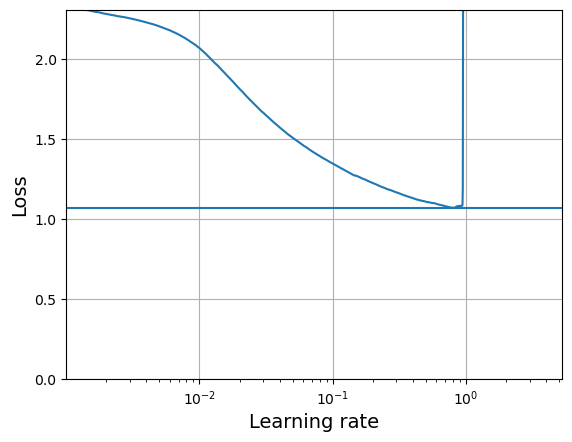

In [23]:
# Graficar la tasa de aprendizaje frente a la pérdida
plt.plot(expon_lr.rates, expon_lr.losses)
plt.gca().set_xscale('log')  # Escala logarítmica en el eje x
plt.hlines(min(expon_lr.losses), min(expon_lr.rates), max(expon_lr.rates))
plt.axis([min(expon_lr.rates), max(expon_lr.rates), 0, expon_lr.losses[0]])
plt.grid()
plt.xlabel("Learning rate")
plt.ylabel("Loss")

### Prueba 2.6e-1

La curva se aplana a un valor de 5.2e-1, así que probaremos autilizar la mitad a 2.6e-1.

In [67]:
# Limpiar cualquier sesión anterior de Keras y establecer semillas para reproducibilidad
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [68]:
# Definir nuevamente el modelo secuencial de Keras
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(400, activation="relu"),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Definir un optimizador SGD con una tasa de aprendizaje de 2.6e-1
optimizer = tf.keras.optimizers.SGD(learning_rate=2.6e-1)

# Compilar el modelo con la función de pérdida sparse_categorical_crossentropy y el optimizador definido
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

# Definir el directorio de logs
run_logdir = Path() / "mnist_logs/exp3/run_001"  # Ruta para almacenar los logs de ejecución

# Crear un callback de EarlyStopping que detendrá el entrenamiento si la pérdida no mejora durante 20 épocas
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20)

# Crear un callback de ModelCheckpoint que guardará el modelo con la mejor puntuación de validación
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("model/exp3/mnist_model.keras", save_best_only=True)

# Crear un callback de TensorBoard para registrar información de entrenamiento en un directorio de logs
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)

# Entrenar el modelo durante 100 épocas, utilizando los callbacks definidos para guardar el mejor modelo, detener temprano y registrar en TensorBoard
history = model.fit(X_train, y_train, epochs=100,
                    validation_data=(X_valid, y_valid),
                    callbacks=[checkpoint_cb, early_stopping_cb, tensorboard_cb])

Epoch 1/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8585 - loss: 0.4476 - val_accuracy: 0.9700 - val_loss: 0.1005
Epoch 2/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9707 - loss: 0.1001 - val_accuracy: 0.9728 - val_loss: 0.0906
Epoch 3/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9819 - loss: 0.0610 - val_accuracy: 0.9762 - val_loss: 0.0850
Epoch 4/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9860 - loss: 0.0443 - val_accuracy: 0.9788 - val_loss: 0.0791
Epoch 5/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9892 - loss: 0.0346 - val_accuracy: 0.9780 - val_loss: 0.0919
Epoch 6/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9913 - loss: 0.0286 - val_accuracy: 0.9818 - val_loss: 0.0735
Epoch 7/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9925 - loss: 0.0229 - val_accuracy: 0.9814 - val_loss: 0.0841
Epoch 8/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9941 - loss: 0

In [69]:
best_val_loss = min(history.history["val_loss"])
best_val_loss_index = history.history["val_loss"].index(best_val_loss)
best_val_accuracy = history.history["val_accuracy"][best_val_loss_index]
accuracy = history.history["accuracy"][best_val_loss_index]
loss = history.history["loss"][best_val_loss_index]

print(f"Resultados: accuracy={accuracy}, loss={loss}, val_accuracy={best_val_accuracy}, val_loss={best_val_loss}")    

Resultados: accuracy=0.990781843662262, loss=0.02991362288594246, val_accuracy=0.9818000197410583, val_loss=0.07349234074354172


In [70]:
# Cargar el modelo guardado
model = tf.keras.models.load_model("model/exp3/mnist_model.keras")

# Evaluar el modelo cargado con los datos de prueba
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9757 - loss: 0.0905


[0.07297517359256744, 0.9793999791145325]

## Experimento 4: Cambiar learning_rate para la mejor red de 4 capas

Y comparar con el resultado obtenido en el Experimento 2.

In [27]:
# Limpiar cualquier sesión anterior de Keras
tf.keras.backend.clear_session()
# Establecer semillas para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

In [28]:
# Definir el modelo con la mejor configuración
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(200, activation="relu"),
    tf.keras.layers.Dense(200, activation="relu"),
    tf.keras.layers.Dense(200, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Definir el optimizador SGD con una tasa de aprendizaje inicial de 1e-3
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-3)

# Compilar el modelo con la función de pérdida sparse_categorical_crossentropy y el optimizador definido
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

# Crear una instancia del callback ExponentialLearningRate con un factor de crecimiento de 1.005
expon_lr = ExponentialLearningRate(factor=1.005)

# Entrenar el modelo con los datos de entrenamiento y validación, utilizando el callback exponencial
# Solo una época
history = model.fit(X_train, y_train, epochs=1,
                    validation_data=(X_valid, y_valid),
                    callbacks=[expon_lr])

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4516 - loss: nan - val_accuracy: 0.0958 - val_loss: nan


Text(0, 0.5, 'Loss')

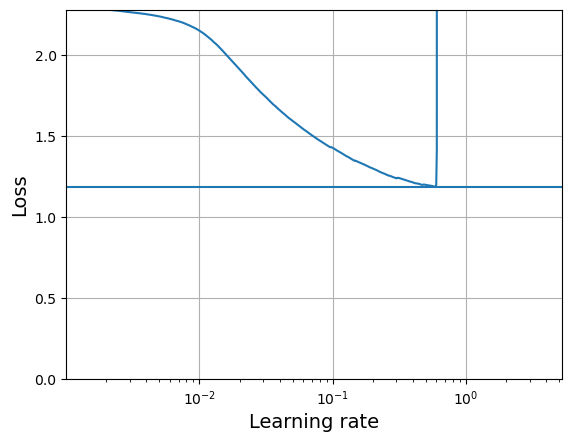

In [29]:
# Graficar la tasa de aprendizaje frente a la pérdida
plt.plot(expon_lr.rates, expon_lr.losses)
plt.gca().set_xscale('log')  # Escala logarítmica en el eje x
plt.hlines(min(expon_lr.losses), min(expon_lr.rates), max(expon_lr.rates))
plt.axis([min(expon_lr.rates), max(expon_lr.rates), 0, expon_lr.losses[0]])
plt.grid()
plt.xlabel("Learning rate")
plt.ylabel("Loss")

### Prueba 3 1.5e-1 - OK

La curva se aplana a un valor de 3e-1, así que probaremos a utilizar la mitad 1.5e-1.

In [39]:
# Limpiar cualquier sesión anterior de Keras y establecer semillas para reproducibilidad
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [40]:
# Definir nuevamente el modelo secuencial de Keras
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(200, activation="relu"),
    tf.keras.layers.Dense(200, activation="relu"),
    tf.keras.layers.Dense(200, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Definir un optimizador SGD con una tasa de aprendizaje de 1.5e-1
optimizer = tf.keras.optimizers.SGD(learning_rate=1.5e-1)

# Compilar el modelo con la función de pérdida sparse_categorical_crossentropy y el optimizador definido
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

# Definir el directorio de logs
run_logdir = Path() / "mnist_logs/exp4/run_001"  # Ruta para almacenar los logs de ejecución

# Crear un callback de EarlyStopping que detendrá el entrenamiento si la pérdida no mejora durante 20 épocas
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20)

# Crear un callback de ModelCheckpoint que guardará el modelo con la mejor puntuación de validación
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("model/exp4/mnist_model.keras", save_best_only=True)

# Crear un callback de TensorBoard para registrar información de entrenamiento en un directorio de logs
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)

# Entrenar el modelo durante 100 épocas, utilizando los callbacks definidos para guardar el mejor modelo, detener temprano y registrar en TensorBoard
history = model.fit(X_train, y_train, epochs=100,
                    validation_data=(X_valid, y_valid),
                    callbacks=[checkpoint_cb, early_stopping_cb, tensorboard_cb])

Epoch 1/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8377 - loss: 0.5054 - val_accuracy: 0.9680 - val_loss: 0.1096
Epoch 2/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9660 - loss: 0.1129 - val_accuracy: 0.9768 - val_loss: 0.0838
Epoch 3/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9788 - loss: 0.0694 - val_accuracy: 0.9766 - val_loss: 0.0823
Epoch 4/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9851 - loss: 0.0489 - val_accuracy: 0.9784 - val_loss: 0.0847
Epoch 5/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9879 - loss: 0.0378 - val_accuracy: 0.9796 - val_loss: 0.0882
Epoch 6/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9898 - loss: 0.0307 - val_accuracy: 0.9776 - val_loss: 0.0868
Epoch 7/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9915 - loss: 0.0274 - val_accuracy: 0.9800 - val_loss: 0.0821
Epoch 8/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9928 - loss: 0

In [41]:
best_val_loss = min(history.history["val_loss"])
best_val_loss_index = history.history["val_loss"].index(best_val_loss)
best_val_accuracy = history.history["val_accuracy"][best_val_loss_index]
accuracy = history.history["accuracy"][best_val_loss_index]
loss = history.history["loss"][best_val_loss_index]

print(f"Resultados: accuracy={accuracy}, loss={loss}, val_accuracy={best_val_accuracy}, val_loss={best_val_loss}")                    

Resultados: accuracy=0.9981818199157715, loss=0.006030650809407234, val_accuracy=0.9837999939918518, val_loss=0.07685953378677368


In [42]:
# Cargar el modelo guardado
model = tf.keras.models.load_model("model/exp4/mnist_model.keras")

# Evaluar el modelo cargado con los datos de prueba
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 933us/step - accuracy: 0.9789 - loss: 0.0948


[0.08025086671113968, 0.9824000000953674]

### Prueba 3 1.5e-1 - re1

La curva se aplana a un valor de 3e-1, así que probaremos a utilizar la mitad 1.5e-1.

In [87]:
# Limpiar cualquier sesión anterior de Keras y establecer semillas para reproducibilidad
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [88]:
# Definir nuevamente el modelo secuencial de Keras
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(200, activation="relu"),
    tf.keras.layers.Dense(200, activation="relu"),
    tf.keras.layers.Dense(200, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Definir un optimizador SGD con una tasa de aprendizaje de 1.5e-1
optimizer = tf.keras.optimizers.SGD(learning_rate=1.5e-1)

# Compilar el modelo con la función de pérdida sparse_categorical_crossentropy y el optimizador definido
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

# Definir el directorio de logs
run_logdir = Path() / "mnist_logs/exp4/run_001"  # Ruta para almacenar los logs de ejecución

# Crear un callback de EarlyStopping que detendrá el entrenamiento si la pérdida no mejora durante 20 épocas
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20)

# Crear un callback de ModelCheckpoint que guardará el modelo con la mejor puntuación de validación
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("model/exp4/mnist_model.keras", save_best_only=True)

# Crear un callback de TensorBoard para registrar información de entrenamiento en un directorio de logs
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)

# Entrenar el modelo durante 100 épocas, utilizando los callbacks definidos para guardar el mejor modelo, detener temprano y registrar en TensorBoard
history = model.fit(X_train, y_train, epochs=100,
                    validation_data=(X_valid, y_valid),
                    callbacks=[checkpoint_cb, early_stopping_cb, tensorboard_cb])

Epoch 1/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8372 - loss: 0.5114 - val_accuracy: 0.9678 - val_loss: 0.1075
Epoch 2/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9673 - loss: 0.1096 - val_accuracy: 0.9766 - val_loss: 0.0767
Epoch 3/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9796 - loss: 0.0698 - val_accuracy: 0.9794 - val_loss: 0.0769
Epoch 4/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9851 - loss: 0.0487 - val_accuracy: 0.9762 - val_loss: 0.0851
Epoch 5/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9871 - loss: 0.0408 - val_accuracy: 0.9794 - val_loss: 0.0738
Epoch 6/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9911 - loss: 0.0295 - val_accuracy: 0.9784 - val_loss: 0.0770
Epoch 7/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9932 - loss: 0.0230 - val_accuracy: 0.9756 - val_loss: 0.0963
Epoch 8/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9922 - loss: 0

In [89]:
best_val_loss = min(history.history["val_loss"])
best_val_loss_index = history.history["val_loss"].index(best_val_loss)
best_val_accuracy = history.history["val_accuracy"][best_val_loss_index]
accuracy = history.history["accuracy"][best_val_loss_index]
loss = history.history["loss"][best_val_loss_index]

print(f"Resultados: accuracy={accuracy}, loss={loss}, val_accuracy={best_val_accuracy}, val_loss={best_val_loss}")                    

Resultados: accuracy=0.9876545667648315, loss=0.039259929209947586, val_accuracy=0.9793999791145325, val_loss=0.07376706600189209


In [90]:
# Cargar el modelo guardado
model = tf.keras.models.load_model("model/exp4/mnist_model.keras")

# Evaluar el modelo cargado con los datos de prueba
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9729 - loss: 0.0959


[0.07744680345058441, 0.9771999716758728]